# Aligning Llama 2 with DPO : From Imitation to Preference

> **Curriculum position:** Notebook 12 of 12 — the alignment capstone of the *AI Researcher Basic* series.  
> **Prerequisites:** `Fine_tune_Llama2_QLoRA_v3.ipynb` — you should already have a fine-tuned Llama 2 adapter.

---

## What This Notebook Does

In the previous notebook we used **QLoRA** to teach Llama 2 a new style via supervised imitation. In this notebook we go one step further: we teach the model **what humans prefer** — not just what they said, but which of two responses is *better*.

By the end you will have:

1. A deep understanding of why SFT is insufficient for alignment
2. A working knowledge of Reinforcement Learning as it applies to LLMs
3. A clear grasp of RLHF and why it works
4. A complete implementation of **DPO** (Direct Preference Optimization) — the modern alternative to PPO-based RLHF
5. A fine-tuned, preference-aligned Llama 2 model

---

## Table of Contents

1. [Why SFT Is Not Enough](#1-why-sft)
2. [Reinforcement Learning for LLMs](#2-rl)
3. [RLHF: The Full Pipeline](#3-rlhf)
4. [DPO: A Better Way](#4-dpo)
5. [Environment Setup](#5-setup)
6. [Imports](#6-imports)
7. [Configuration](#7-config)
8. [Dataset Loading & Formatting](#8-dataset)
9. [Quantization Configuration](#9-quant)
10. [Load Base Model](#10-model)
11. [Tokenizer Setup](#11-tokenizer)
12. [Training Arguments](#12-args)
13. [DPOTrainer Initialization](#13-trainer)
14. [Pre-Training Baseline Inference](#14-baseline)
15. [Training](#15-train)
16. [Training Loss Visualization](#16-loss)
17. [Post-Training Inference & Comparison](#17-compare)
18. [Save](#18-save)
19. [References & Further Reading](#19-references)

<a id='1-why-sft'></a>
## 1. Why SFT Is Not Enough

### What SFT actually learns

In the QLoRA notebook, we minimised **cross-entropy loss**:

```
L_SFT = - Σ  log P(token_t | token_1...token_{t-1})
        t ∈ response
```

This is a **maximum likelihood objective**: make the model's probability distribution match the training data distribution as closely as possible. In plain English: *learn to sound like the training examples*.

This is powerful — but it has a fundamental problem.

### Three failure modes of SFT

| Failure | What happens | Why SFT can't fix it |
|---|---|---|
| **Hallucination** | Model confidently states false facts | SFT minimises prediction error, not factual accuracy. If training data contains errors, the model learns them. |
| **Sycophancy** | Model agrees with whatever the user says, even if wrong | If human annotators wrote sycophantic responses, the model imitates that too. |
| **Harmful outputs** | Model generates harmful content | SFT on mixed-quality data gives no signal about *which* outputs are desirable. |

### The alignment gap

Consider two possible responses to "Explain quantum entanglement":

- **Response A:** A clear, accurate, well-structured explanation.
- **Response B:** A vague, partially incorrect, verbose response.

If both appear in your training data, SFT treats them **identically** — both are just training examples to imitate. There is no mechanism to prefer A over B.

What we need is a way to tell the model: *this response is better than that one*. That is the alignment problem, and it requires a different learning paradigm entirely.

> **Connection to your earlier work:** Recall from `neural_network/neuron_layers.ipynb` that cross-entropy loss measures the distance between two probability distributions. SFT uses it to match the *training data distribution* — but the training data distribution is not the same as the *human preference distribution*. We need to close that gap.

<a id='2-rl'></a>
## 2. Reinforcement Learning for Language Models

### The RL Paradigm

Reinforcement Learning is a learning framework where an **agent** learns by interacting with an **environment** and receiving **reward signals**.

```
┌─────────────────────────────────────────┐
│                                         │
│   Agent ──── action ────► Environment   │
│     ▲                          │        │
│     └────── reward + state ◄───┘        │
│                                         │
└─────────────────────────────────────────┘
```

For a language model:

| RL concept | LLM equivalent |
|---|---|
| **Agent** | The language model |
| **State** | The conversation history so far |
| **Action** | The next token to generate |
| **Policy** | The probability distribution P(token \| context) |
| **Reward** | A quality score for the completed response |
| **Episode** | A full generation (prompt → response) |

### How RL differs from Supervised Learning

In **supervised learning** (SFT), we have labeled examples: `(input, correct_output)`. The model is told the right answer directly.

In **reinforcement learning**, we have no correct answer — only a **reward signal** after the fact. The model must *explore* different outputs and learn which ones receive higher reward.

This is exactly what we need for alignment:
- We cannot enumerate all "correct" responses (language is infinite)
- But we *can* score responses: humans can say "A is better than B"
- RL lets us optimise for that preference signal

### The Objective

In standard RL, the goal is to find a policy π that maximises expected cumulative reward:

```
π* = argmax_π  𝔼[Σ r_t]
```

For a language model generating a complete response y given prompt x:

```
π* = argmax_π  𝔼_{y ~ π(·|x)} [ r(x, y) ]
```

where r(x, y) is a reward function that scores how good response y is for prompt x.

### The Power of RL: Any Reward We Define

The critical insight: **we can define r(x, y) to be anything we care about**:
- Human ratings of helpfulness
- Factual accuracy (checked against a knowledge base)
- Safety scores (from a classifier)
- Code correctness (run the code and check if it passes tests)

This is what makes RL the right framework for alignment — it lets us inject *any* preference signal into the training process.

<a id='3-rlhf'></a>
## 3. RLHF: Reinforcement Learning from Human Feedback

RLHF, introduced in the **InstructGPT paper** (Ouyang et al., 2022) and used to build ChatGPT, is a three-step process:

```
Step 1: SFT          Step 2: Reward Model       Step 3: RL with PPO
─────────────       ──────────────────────      ────────────────────
Train on             Human labellers            Use PPO to update
demonstrations  →    compare A vs B        →    LLM to maximise
(done in v3!)        Train RM on pairs          reward model score
```

### Step 1: Supervised Fine-Tuning — Done!

You did this in the QLoRA notebook. The SFT model gives us a strong starting point that already knows how to follow instructions.

### Step 2: Reward Model Training

Human labellers are shown pairs of responses (A, B) to the same prompt and asked: *which is better?*

These comparisons are used to train a **reward model** — a classifier that scores any response. The Bradley-Terry model formalises this:

```
P(A is preferred over B) = σ( r(A) - r(B) )
```

where σ is the sigmoid function and r(·) is the learned reward.

### Step 3: PPO — Proximal Policy Optimisation

With a trained reward model, we can use PPO to optimise the LLM:

```
Objective = 𝔼[ r(y) ]  -  β · KL[ π(y|x) || π_ref(y|x) ]
               ↑                        ↑
        maximise reward         don't stray too far
                                from the SFT model
```

The **KL penalty** is crucial: without it, the model would learn to "hack" the reward model — generating text that scores high but is gibberish or degenerate.

### Why PPO is Hard

| Problem | What happens |
|---|---|
| **Complexity** | PPO requires 4 models in memory simultaneously: policy, reference, reward model, value model |
| **Reward hacking** | Model finds outputs that fool the reward model but aren't actually good |
| **Instability** | PPO is notoriously sensitive to hyperparameters |
| **VRAM** | 4 models × ~5 GB each = ~20 GB minimum — too much for most GPUs |

This is where DPO comes in.

<a id='4-dpo'></a>
## 4. DPO: Direct Preference Optimization

DPO (Rafailov et al., 2023) is an elegant reformulation that **skips the reward model entirely** and optimises preferences directly.

### The Key Insight

It turns out that in RLHF, the optimal policy π* has a closed-form solution:

```
π*(y | x)  ∝  π_ref(y | x) · exp( r(x, y) / β )
```

Rearranging, the implicit reward can be expressed in terms of the policy:

```
r(x, y)  =  β · log[ π*(y|x) / π_ref(y|x) ]  +  β · log Z(x)
```

where Z(x) is a partition function that **depends only on x, not y**.

### The DPO Loss

Substituting this into the Bradley-Terry preference model, and noting that Z(x) **cancels** in the comparison (same x for both responses):

```
P(y_w ≻ y_l | x) = σ( β log[π(y_w|x)/π_ref(y_w|x)]  -  β log[π(y_l|x)/π_ref(y_l|x)] )
```

Taking the negative log-likelihood gives the **DPO loss**:

```
L_DPO(π ; π_ref) = -𝔼[ log σ(
    β log π(y_w|x)/π_ref(y_w|x)   ←  increase likelihood of chosen
  - β log π(y_l|x)/π_ref(y_l|x)   ←  decrease likelihood of rejected
) ]
```

### What the Loss Is Doing

For each preference pair (prompt x, chosen y_w, rejected y_l), the loss:

1. **Increases** the log-probability of the chosen response *relative to the reference model*
2. **Decreases** the log-probability of the rejected response *relative to the reference model*
3. The β parameter controls how strongly we enforce preferences vs. staying close to the reference

### DPO vs PPO

| | PPO | DPO |
|---|---|---|
| Reward model needed? | Yes | No |
| Models in memory | 4 | 2 (model + reference) |
| Training stability | Sensitive | Stable |
| Implementation complexity | High | Low |
| Quality | Excellent | Near-identical |

### The Role of β

```
β → 0 : ignore preferences, stay close to reference model (conservative)
β → ∞ : strongly enforce preferences, may diverge from reference (aggressive)
β = 0.1 : typical default — gentle preference signal
```

> **Connection to prior work:** The reference model plays the same role as the KL penalty in PPO — it prevents the model from drifting too far from the sensible SFT baseline. The ratio π(y)/π_ref(y) is the implicit reward we're optimising.

<a id='5-setup'></a>
## 5. Environment Setup

Same pinned packages as the QLoRA notebook. `bitsandbytes` is intentionally unpinned to always match Colab's CUDA version.

> **Google Colab users:** After the install cell, go to **Runtime → Restart session**, then **Run all**.

In [1]:
print("=" * 60)
print("STEP 1/10 — Installing packages")
print("=" * 60)

try:
    import subprocess, sys
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "transformers==4.44.2",
         "peft==0.12.0",
         "trl==0.9.6",
         "bitsandbytes",
         "accelerate==0.33.0",
         "datasets==2.21.0",
         "matplotlib"],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print("\u274c pip install failed:")
        print(result.stderr)
    else:
        r2 = subprocess.run(
            [sys.executable, "-m", "pip", "show", "bitsandbytes"],
            capture_output=True, text=True
        )
        for line in r2.stdout.splitlines():
            if line.startswith("Version"):
                print(f"\u2713 bitsandbytes {line}")
        print("\u2713 All other packages installed at pinned versions.")
        print("\u26a0\ufe0f  Colab: Runtime \u2192 Restart session \u2192 Run all")
except Exception as e:
    print(f"\u274c Unexpected error: {e}")

STEP 1/10 — Installing packages
✓ bitsandbytes Version: 0.49.2
✓ All other packages installed at pinned versions.
⚠️  Colab: Runtime → Restart session → Run all


In [2]:
import os

USE_DRIVE = True

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_BASE = "/content/drive/MyDrive/llama2_dpo"
        os.makedirs(DRIVE_BASE, exist_ok=True)
        OUTPUT_DIR = f"{DRIVE_BASE}/results"
        NEW_MODEL  = f"{DRIVE_BASE}/Llama-2-7b-dpo"
        print(f"\u2713 Google Drive mounted.")
        print(f"  Checkpoints : {OUTPUT_DIR}")
        print(f"  Adapter     : {NEW_MODEL}")
    except ImportError:
        print("Not on Google Colab \u2014 Drive mount skipped.")
        OUTPUT_DIR = "./results"
        NEW_MODEL  = "Llama-2-7b-dpo"
else:
    OUTPUT_DIR = "./results"
    NEW_MODEL  = "Llama-2-7b-dpo"
    print("Drive not mounted. Files saved to current directory.")

Mounted at /content/drive
✓ Google Drive mounted.
  Checkpoints : /content/drive/MyDrive/llama2_dpo/results
  Adapter     : /content/drive/MyDrive/llama2_dpo/Llama-2-7b-dpo


In [3]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU    : {gpu_name}")
    print(f"VRAM   : {vram_gb:.1f} GB")
    print(f"CUDA   : {torch.version.cuda}")
    print(f"PyTorch: {torch.__version__}")
    if vram_gb < 12:
        print("\n\u26a0\ufe0f  Less than 12 GB VRAM. Set BATCH_SIZE=1 and reduce MAX_LENGTH.")
    else:
        print("\n\u2713 VRAM looks sufficient for DPO fine-tuning.")
else:
    print("\u274c No CUDA GPU detected. Runtime \u2192 Change runtime type \u2192 T4 GPU")

GPU    : Tesla T4
VRAM   : 15.6 GB
CUDA   : 12.8
PyTorch: 2.11.0+cu128

✓ VRAM looks sufficient for DPO fine-tuning.


<a id='6-imports'></a>
## 6. Imports

Same libraries as QLoRA, with two additions: `DPOTrainer` from `trl` and `prepare_model_for_kbit_training` from `peft` (needed before applying LoRA to a quantized model).

In [15]:
print("=" * 60)
print("STEP 2/10 \u2014 Importing libraries")
print("=" * 60)

try:
    import gc
    import warnings
    import matplotlib.pyplot as plt
    print("\u2713 gc, warnings, matplotlib")

    import torch
    print(f"\u2713 torch {torch.__version__}")

    from datasets import load_dataset
    import datasets as ds_lib
    print(f"\u2713 datasets {ds_lib.__version__}")

    from transformers import (
        AutoModelForCausalLM,
        AutoTokenizer,
        BitsAndBytesConfig,
        TrainingArguments,
        pipeline,
        logging as hf_logging,
    )
    import transformers
    print(f"\u2713 transformers {transformers.__version__}")

    from peft import (
        LoraConfig,
        PeftModel,
        get_peft_model,
        prepare_model_for_kbit_training,
    )
    import peft
    print(f"\u2713 peft {peft.__version__}")

    from trl import DPOTrainer, DPOConfig
    import trl
    print(f"\u2713 trl {trl.__version__}")

    import bitsandbytes as bnb
    print(f"\u2713 bitsandbytes {bnb.__version__}")

    hf_logging.set_verbosity_warning()
    warnings.filterwarnings("ignore")
    print("\n\u2713 All imports successful.")

except ImportError as e:
    print(f"\n\u274c Import failed: {e}")
    print("   \u2192 Did you restart the session after the install cell?")

STEP 2/10 — Importing libraries
✓ gc, warnings, matplotlib
✓ torch 2.11.0+cu128
✓ datasets 2.21.0
✓ transformers 4.44.2
✓ peft 0.12.0
✓ trl 0.9.6
✓ bitsandbytes 0.49.2

✓ All imports successful.


<a id='7-config'></a>
## 7. Configuration

Three new variables compared to the QLoRA notebook:

| Variable | Default | Meaning |
|---|---|---|
| `DPO_BETA` | 0.1 | Preference temperature — lower stays closer to reference model |
| `MAX_LENGTH` | 512 | Total token budget (prompt + response) |
| `MAX_PROMPT_LENGTH` | 256 | Maximum tokens for the prompt alone — rest goes to the response |

We also use `BATCH_SIZE=1` because DPO requires **4 forward passes** per step (model + reference × chosen + rejected), which doubles memory vs SFT.

In [5]:
# ===================================================================
# MODEL
# ===================================================================
MODEL_ID  = "NousResearch/Llama-2-7b-chat-hf"
# Same public mirror as QLoRA notebook. No HF token required.

# ===================================================================
# DATASET
# ===================================================================
DATASET_ID   = "Intel/orca_dpo_pairs"
# Orca-style preference pairs: system + question + chosen + rejected.
# ~12k examples total; we sample 1k for a ~30 min Colab run.
DATASET_SIZE = 1000

# ===================================================================
# LoRA HYPERPARAMETERS
# ===================================================================
LORA_R       = 16    # Lower than QLoRA (64) — DPO needs less capacity
LORA_ALPHA   = 32    # scale = alpha/r = 2.0
LORA_DROPOUT = 0.05

# ===================================================================
# QUANTIZATION
# ===================================================================
USE_4BIT          = True
BNB_COMPUTE_DTYPE = "float16"
BNB_QUANT_TYPE    = "nf4"
USE_NESTED_QUANT  = False

# ===================================================================
# DPO SPECIFIC
# ===================================================================
DPO_BETA         = 0.1   # Preference temperature (0.05-0.5 typical range)
MAX_LENGTH       = 512   # Total sequence length: prompt + response
MAX_PROMPT_LENGTH= 256   # Max tokens for the prompt portion

# ===================================================================
# TRAINING HYPERPARAMETERS
# ===================================================================
NUM_EPOCHS           = 1
BATCH_SIZE           = 1     # Must be 1 on T4: DPO = 4x forward passes per step
GRADIENT_ACCUM_STEPS = 4     # Effective batch = 1x4 = 4
LEARNING_RATE        = 5e-5  # Lower than SFT (2e-4) — DPO is more sensitive
WEIGHT_DECAY         = 0.001
MAX_GRAD_NORM        = 0.3
WARMUP_RATIO         = 0.1
LR_SCHEDULER         = "cosine"
OPTIMIZER            = "paged_adamw_32bit"

print("Configuration loaded.")
print(f"  Model    : {MODEL_ID}")
print(f"  Dataset  : {DATASET_ID} ({DATASET_SIZE} examples)")
print(f"  DPO beta : {DPO_BETA}")
print(f"  Max len  : {MAX_LENGTH} tokens  (prompt: {MAX_PROMPT_LENGTH})")
print(f"  LR       : {LEARNING_RATE}  |  Effective batch: {BATCH_SIZE * GRADIENT_ACCUM_STEPS}")

Configuration loaded.
  Model    : NousResearch/Llama-2-7b-chat-hf
  Dataset  : Intel/orca_dpo_pairs (1000 examples)
  DPO beta : 0.1
  Max len  : 512 tokens  (prompt: 256)
  LR       : 5e-05  |  Effective batch: 4


<a id='8-dataset'></a>
## 8. Dataset Loading & Formatting

### The Intel Orca DPO Dataset

`Intel/orca_dpo_pairs` contains preference pairs derived from the Orca dataset. Each example has:

| Column | Content |
|---|---|
| `system` | System prompt (persona/instructions) |
| `question` | User's question |
| `chosen` | GPT-4 response (the preferred output) |
| `rejected` | GPT-3.5 response (the less preferred output) |

### Required Format for DPOTrainer

`DPOTrainer` expects exactly three columns:

| Column | Content |
|---|---|
| `prompt` | The instruction in Llama 2 chat template |
| `chosen` | The preferred response text |
| `rejected` | The non-preferred response text |

We write a `format_to_llama2()` function to convert the dataset into this format.

In [6]:
print("=" * 60)
print("STEP 3/10 \u2014 Loading and formatting dataset")
print("=" * 60)

try:
    raw_dataset = load_dataset(DATASET_ID, split="train")
    print(f"\u2713 Raw dataset: {len(raw_dataset)} examples")
    print(f"  Columns: {raw_dataset.column_names}")

    # Sample to keep training time manageable on T4
    raw_dataset = raw_dataset.select(range(DATASET_SIZE))
    print(f"\u2713 Sampled to {DATASET_SIZE} examples")

    def format_to_llama2(example):
        """Convert Orca columns to Llama 2 chat template + DPOTrainer format."""
        system   = (example.get('system') or '').strip()
        question = example['question'].strip()

        if system:
            prompt = (
                f"<s>[INST] <<SYS>>\n{system}\n<</SYS>>\n\n{question} [/INST]"
            )
        else:
            prompt = f"<s>[INST] {question} [/INST]"

        return {
            'prompt'  : prompt,
            'chosen'  : example['chosen'].strip(),
            'rejected': example['rejected'].strip(),
        }

    dataset = raw_dataset.map(
        format_to_llama2,
        remove_columns=raw_dataset.column_names,
    )
    print(f"\u2713 Dataset formatted. Columns: {dataset.column_names}")

except Exception as e:
    print(f"\u274c Dataset loading failed: {e}")
    import traceback; traceback.print_exc()

STEP 3/10 — Loading and formatting dataset


Generating train split:   0%|          | 0/12859 [00:00<?, ? examples/s]

✓ Raw dataset: 12859 examples
  Columns: ['system', 'question', 'chosen', 'rejected']
✓ Sampled to 1000 examples


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

✓ Dataset formatted. Columns: ['chosen', 'rejected', 'prompt']


In [7]:
# Inspect one example to confirm formatting
example = dataset[0]
print("PROMPT:")
print(example['prompt'][:300], "..." if len(example['prompt']) > 300 else "")
print("\nCHOSEN (first 200 chars):")
print(example['chosen'][:200])
print("\nREJECTED (first 200 chars):")
print(example['rejected'][:200])

PROMPT:
<s>[INST] You will be given a definition of a task first, then some input of the task.
This task is about using the specified sentence and converting the sentence to Resource Description Framework (RDF) triplets of the form (subject, predicate object). The RDF triplets generated must be such that th ...

CHOSEN (first 200 chars):
[
  ["AFC Ajax (amateurs)", "has ground", "Sportpark De Toekomst"],
  ["Ajax Youth Academy", "plays at", "Sportpark De Toekomst"]
]

REJECTED (first 200 chars):
Sure, I'd be happy to help! Here are the RDF triplets for the input sentence:

[AFC Ajax (amateurs), hasGround, Sportpark De Toekomst]
[Ajax Youth Academy, playsAt, Sportpark De Toekomst]

Explanation


<a id='9-quant'></a>
## 9. Quantization Configuration

Same NF4 4-bit setup as the QLoRA notebook. See `Fine_tune_Llama2_QLoRA_v3.ipynb` Section 7 for the full explanation.

In [8]:
print("=" * 60)
print("STEP 4/10 \u2014 Quantization config")
print("=" * 60)

try:
    compute_dtype = getattr(torch, BNB_COMPUTE_DTYPE)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = USE_4BIT,
        bnb_4bit_quant_type       = BNB_QUANT_TYPE,
        bnb_4bit_compute_dtype    = compute_dtype,
        bnb_4bit_use_double_quant = USE_NESTED_QUANT,
    )
    print(f"\u2713 BitsAndBytesConfig: {BNB_QUANT_TYPE}, compute={BNB_COMPUTE_DTYPE}")

except Exception as e:
    print(f"\u274c Quantization config failed: {e}")
    print("   \u2192 Run: !pip show bitsandbytes")

STEP 4/10 — Quantization config
✓ BitsAndBytesConfig: nf4, compute=float16


<a id='10-model'></a>
## 10. Load Base Model

Two extra steps compared to QLoRA:

1. **`prepare_model_for_kbit_training(model)`** — enables gradient computation through quantized layers by upcasting LayerNorm weights to fp32 and enabling gradient checkpointing hooks.
2. **`get_peft_model(model, peft_config)`** — wraps the model with LoRA adapter matrices.

When we pass this `PeftModel` to `DPOTrainer` with `ref_model=None`, TRL automatically uses the base model (adapter layers disabled) as the frozen reference. This means only **one model is in GPU memory**, not two — saving ~5 GB VRAM.

In [9]:
print("=" * 60)
print("STEP 5/10 \u2014 Loading and preparing model (2-5 min)")
print("=" * 60)

try:
    vram_before = torch.cuda.memory_allocated(0) / 1e9
    print(f"  VRAM before : {vram_before:.2f} GB")
    print(f"  Loading     : {MODEL_ID} ...")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config = bnb_config,
        device_map          = {"": 0},
        torch_dtype         = torch.float16,
    )
    model.config.use_cache = False
    model.config.pretraining_tp = 1

    # Cast any stray bfloat16 tensors (T4 does not support bf16 in AMP)
    bf16_count = sum(1 for p in model.parameters() if p.dtype == torch.bfloat16)
    if bf16_count > 0:
        print(f"  \u26a0\ufe0f  Casting {bf16_count} bfloat16 tensor(s) to float16 ...")
        for p in model.parameters():
            if p.dtype == torch.bfloat16:
                p.data = p.data.to(torch.float16)

    # Prepare for k-bit training (enables grads through quantized layers)
    print("  Preparing model for k-bit training ...")
    model = prepare_model_for_kbit_training(model)

    # Apply LoRA adapters
    peft_config = LoraConfig(
        r          = LORA_R,
        lora_alpha = LORA_ALPHA,
        lora_dropout = LORA_DROPOUT,
        bias       = "none",
        task_type  = "CAUSAL_LM",
    )
    model = get_peft_model(model, peft_config)

    vram_after = torch.cuda.memory_allocated(0) / 1e9
    print(f"\n\u2713 Model ready.")
    print(f"  VRAM after  : {vram_after:.2f} GB")
    model.print_trainable_parameters()

except torch.cuda.OutOfMemoryError:
    print("\u274c OUT OF MEMORY loading the model.")
    print("   \u2192 Set USE_NESTED_QUANT=True, or restart and try again.")
except Exception as e:
    print(f"\u274c Model loading failed: {e}")
    import traceback; traceback.print_exc()

STEP 5/10 — Loading and preparing model (2-5 min)
  VRAM before : 0.00 GB
  Loading     : NousResearch/Llama-2-7b-chat-hf ...


config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

  Preparing model for k-bit training ...

✓ Model ready.
  VRAM after  : 4.78 GB
trainable params: 8,388,608 || all params: 6,746,804,224 || trainable%: 0.1243


<a id='11-tokenizer'></a>
## 11. Tokenizer Setup

Identical to the QLoRA notebook. We reuse EOS as the padding token and pad on the right.

In [10]:
print("=" * 60)
print("STEP 6/10 \u2014 Tokenizer setup")
print("=" * 60)

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    print(f"\u2713 Tokenizer loaded:")
    print(f"  Vocab size   : {tokenizer.vocab_size:,}")
    print(f"  PAD token    : '{tokenizer.pad_token}'  (id: {tokenizer.pad_token_id})")
    print(f"  Padding side : {tokenizer.padding_side}")

except Exception as e:
    print(f"\u274c Tokenizer loading failed: {e}")

STEP 6/10 — Tokenizer setup


tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

✓ Tokenizer loaded:
  Vocab size   : 32,000
  PAD token    : '</s>'  (id: 2)
  Padding side : right


<a id='12-args'></a>
## 12. Training Arguments

We use standard `TrainingArguments` (not `SFTConfig`) because `DPOTrainer` takes its own `beta`, `max_length`, and `max_prompt_length` parameters separately.

Key differences from the QLoRA training arguments:
- `BATCH_SIZE = 1` — DPO requires 4 forward passes per step (model + reference × chosen + rejected)
- `LEARNING_RATE = 5e-5` — lower than SFT because DPO is more sensitive to LR
- `WARMUP_RATIO = 0.1` — longer warmup (10% vs 3%) for stability
- `remove_unused_columns = False` — DPOTrainer needs the raw prompt/chosen/rejected columns

In [16]:
print("=" * 60)
print("STEP 7/10 \u2014 Training arguments")
print("=" * 60)

try:
    training_args = DPOConfig(
      output_dir                  = OUTPUT_DIR,
      num_train_epochs            = NUM_EPOCHS,
      per_device_train_batch_size = BATCH_SIZE,
      gradient_accumulation_steps = GRADIENT_ACCUM_STEPS,
      gradient_checkpointing      = True,
      optim                       = OPTIMIZER,
      logging_steps               = 10,
      save_strategy               = "epoch",
      learning_rate               = LEARNING_RATE,
      weight_decay                = WEIGHT_DECAY,
      fp16                        = True,
      bf16                        = False,
      max_grad_norm               = MAX_GRAD_NORM,
      warmup_ratio                = WARMUP_RATIO,
      lr_scheduler_type           = LR_SCHEDULER,
      report_to                   = "none",
      remove_unused_columns       = False,
      beta                        = DPO_BETA,
      max_length                  = MAX_LENGTH,
      max_prompt_length           = MAX_PROMPT_LENGTH,
  )

    effective_batch = BATCH_SIZE * GRADIENT_ACCUM_STEPS
    steps_per_epoch = DATASET_SIZE // effective_batch
    print(f"\u2713 TrainingArguments created:")
    print(f"  Effective batch size : {effective_batch}")
    print(f"  Steps per epoch      : {steps_per_epoch}")
    print(f"  Learning rate        : {LEARNING_RATE}")
    print(f"  Mixed precision      : fp16=True, bf16=False")

except TypeError as e:
    print(f"\u274c TrainingArguments init failed: {e}")
except Exception as e:
    print(f"\u274c Unexpected error: {e}")

STEP 7/10 — Training arguments
✓ TrainingArguments created:
  Effective batch size : 4
  Steps per epoch      : 250
  Learning rate        : 5e-05
  Mixed precision      : fp16=True, bf16=False


<a id='13-trainer'></a>
## 13. DPOTrainer Initialization

### Key Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `model` | PeftModel | The LoRA-wrapped model to train |
| `ref_model` | `None` | Use base model (adapter disabled) as reference — memory efficient |
| `beta` | 0.1 | Preference temperature — see Section 4 |
| `max_length` | 512 | Total sequence length budget |
| `max_prompt_length` | 256 | Prompt gets up to half the budget |

### How `ref_model=None` Works

When `ref_model=None` and the model is a `PeftModel`, `DPOTrainer` calls `model.disable_adapter_layers()` during the reference forward pass. This temporarily turns off the LoRA adapters, effectively using the frozen base model as the reference. No second model is loaded into memory.

In [17]:
print("=" * 60)
print("STEP 8/10 \u2014 Initialising DPOTrainer")
print("=" * 60)

try:
    dpo_trainer = DPOTrainer(
        model            = model,
        ref_model        = None,          # base model used as reference via PEFT
        args             = training_args,
        beta             = DPO_BETA,
        train_dataset    = dataset,
        tokenizer        = tokenizer,
       # max_length       = MAX_LENGTH, #dpoconfig hanles it
       # max_prompt_length= MAX_PROMPT_LENGTH,
    )
    print("\u2713 DPOTrainer initialised.")
    print(f"  beta             : {DPO_BETA}")
    print(f"  max_length       : {MAX_LENGTH}")
    print(f"  max_prompt_length: {MAX_PROMPT_LENGTH}")
    print(f"  ref_model        : None (PEFT adapter-disable approach)")

except TypeError as e:
    print(f"\u274c DPOTrainer init failed: {e}")
    print("   \u2192 A parameter name may differ in this trl version.")
    print("   \u2192 Run: !pip show trl")
except torch.cuda.OutOfMemoryError:
    print("\u274c OUT OF MEMORY during trainer init.")
    print("   \u2192 Reduce MAX_LENGTH or restart the runtime.")
except Exception as e:
    print(f"\u274c Unexpected error: {e}")
    import traceback; traceback.print_exc()

STEP 8/10 — Initialising DPOTrainer


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

✓ DPOTrainer initialised.
  beta             : 0.1
  max_length       : 512
  max_prompt_length: 256
  ref_model        : None (PEFT adapter-disable approach)


<a id='14-baseline'></a>
## 14. Pre-Training Baseline Inference

Record the model's response before DPO training so we can compare afterwards.

In [18]:
TEST_PROMPT = "<s>[INST] Explain the difference between a good explanation and a bad one. [/INST]"

dpo_trainer.model.config.use_cache = True

pipe = pipeline(
    task           = "text-generation",
    model          = dpo_trainer.model,
    tokenizer      = tokenizer,
    max_new_tokens = 200,
    do_sample      = False,
)

result_before = pipe(TEST_PROMPT)[0]["generated_text"]

print("=" * 60)
print("BASELINE (before DPO):")
print("=" * 60)
print(result_before)

dpo_trainer.model.config.use_cache = False
del pipe
gc.collect()
torch.cuda.empty_cache()

The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausalLM', 'MambaForCausalLM', 'Mamba2ForCausalLM', 'MarianForCausalLM', 'MBartForCausalLM', 'MegaForCausalLM', 'MegatronBertForCausalLM', 'MistralForCausalLM', 'MixtralForCausal

BASELINE (before DPO):
<s>[INST] Explain the difference between a good explanation and a bad one. [/INST]  A good explanation is one that effectively conveys information, ideas, or concepts in a clear, concise, and understandable manner. A bad explanation, on the other hand, is one that fails to do so, often leaving the listener or reader confused, frustrated, or disinterested. Here are some key differences between a good and a bad explanation:

1. Clarity: A good explanation is clear and concise, using simple language and avoiding technical jargon or complex concepts that may confuse the listener or reader. A bad explanation may be too vague, ambiguous, or convoluted, making it difficult for the listener or reader to follow.
2. Relevance: A good explanation is relevant to the topic or issue at hand, addressing the key points and providing context where necessary. A bad explanation may be off-topic, irrelevant, or unrelated to the issue being discussed.
3. Organization: A good


<a id='15-train'></a>
## 15. Training

### What Happens Each Step

For each batch of preference pairs (prompt, chosen, rejected):

1. **Four forward passes:**
   - `log π_θ(chosen | prompt)` — trained model on chosen
   - `log π_θ(rejected | prompt)` — trained model on rejected
   - `log π_ref(chosen | prompt)` — reference (adapter disabled) on chosen
   - `log π_ref(rejected | prompt)` — reference on rejected

2. **DPO loss:**
   ```
   L = -log σ( β·(log π_θ/π_ref for chosen) - β·(log π_θ/π_ref for rejected) )
   ```

3. **Gradient update:** only the LoRA adapter weights are updated.

### Reading the Log

| Column | Meaning |
|---|---|
| `loss` | DPO loss (expect 0.5-0.7 early, decreasing) |
| `rewards/chosen` | Avg implicit reward for chosen responses (should increase) |
| `rewards/rejected` | Avg implicit reward for rejected responses (should decrease) |
| `rewards/margins` | chosen - rejected (should be positive and growing) |

In [19]:
print("=" * 60)
print("STEP 9/10 \u2014 Training (~30 min on T4)")
print("=" * 60)

try:
    train_result = dpo_trainer.train()

    dpo_trainer.model.save_pretrained(NEW_MODEL)

    print(f"\n\u2713 Training complete!")
    print(f"  Training loss   : {train_result.training_loss:.4f}")
    print(f"  Runtime         : {train_result.metrics['train_runtime']:.0f}s  ({train_result.metrics['train_runtime']/60:.1f} min)")
    print(f"  Samples/second  : {train_result.metrics['train_samples_per_second']:.3f}")
    print(f"  Adapter saved to: {NEW_MODEL}")

except torch.cuda.OutOfMemoryError:
    print("\u274c OUT OF MEMORY during training.")
    print("   \u2192 BATCH_SIZE is already 1. Try reducing MAX_LENGTH to 384.")
except Exception as e:
    print(f"\u274c Training failed: {e}")
    import traceback; traceback.print_exc()

STEP 9/10 — Training (~30 min on T4)


Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,0.682800
20,0.595600
30,0.468800
40,0.315200
50,0.223400
60,0.145700
70,0.039700
80,0.032100
90,0.010400
100,0.006200



✓ Training complete!
  Training loss   : 0.1169
  Runtime         : 3517s  (58.6 min)
  Samples/second  : 0.284
  Adapter saved to: /content/drive/MyDrive/llama2_dpo/Llama-2-7b-dpo


<a id='16-loss'></a>
## 16. Training Loss Visualization

DPO logs several reward metrics in addition to the loss. We plot all of them:

- **Loss** — DPO loss (should decrease)
- **rewards/chosen** — implicit reward for preferred responses (should increase)
- **rewards/rejected** — implicit reward for dispreferred responses (should decrease or stay lower)
- **rewards/margins** — gap between chosen and rejected rewards (should increase — model is learning to discriminate)

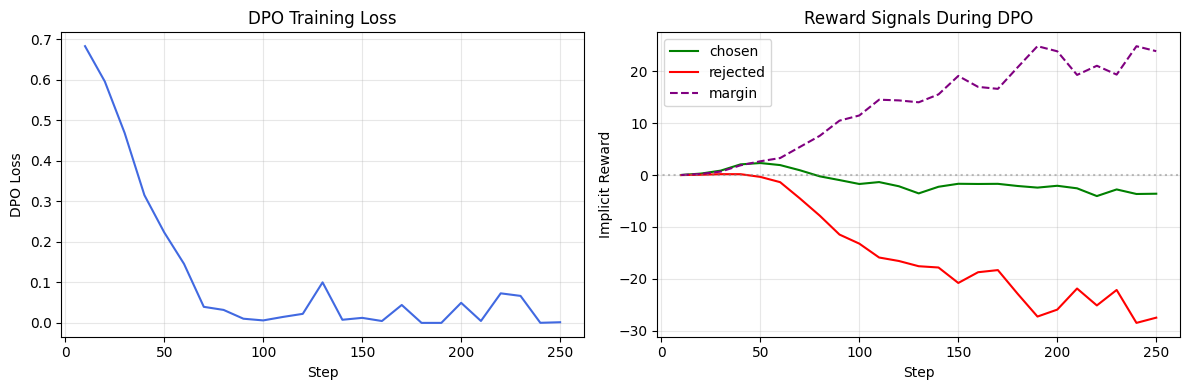

Final loss   : 0.0017


In [20]:
log_history = dpo_trainer.state.log_history

steps          = [e["step"]              for e in log_history if "loss" in e]
losses         = [e["loss"]              for e in log_history if "loss" in e]
rew_chosen     = [e.get("rewards/chosen",   None) for e in log_history if "loss" in e]
rew_rejected   = [e.get("rewards/rejected", None) for e in log_history if "loss" in e]
rew_margins    = [e.get("rewards/margins",  None) for e in log_history if "loss" in e]

if steps:
    has_rewards = any(v is not None for v in rew_chosen)
    n_plots = 2 if has_rewards else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(12 if has_rewards else 7, 4))
    if n_plots == 1:
        axes = [axes]

    axes[0].plot(steps, losses, color="royalblue", linewidth=1.5)
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("DPO Loss")
    axes[0].set_title("DPO Training Loss")
    axes[0].grid(alpha=0.3)

    if has_rewards:
        if any(v is not None for v in rew_chosen):
            axes[1].plot(steps, rew_chosen,   label="chosen",   color="green")
        if any(v is not None for v in rew_rejected):
            axes[1].plot(steps, rew_rejected, label="rejected", color="red")
        if any(v is not None for v in rew_margins):
            axes[1].plot(steps, rew_margins,  label="margin",   color="purple", linestyle="--")
        axes[1].axhline(0, color="gray", linestyle=":", alpha=0.5)
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Implicit Reward")
        axes[1].set_title("Reward Signals During DPO")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"Final loss   : {losses[-1]:.4f}")
else:
    print("No log data found.")

<a id='17-compare'></a>
## 17. Post-Training Inference & Comparison

Compare responses to the same prompt before and after DPO. With 1k examples and 1 epoch, the change may be subtle — the model should show slightly more structured, direct responses aligned with the preferred Orca completions style.

In [21]:
dpo_trainer.model.config.use_cache = True

pipe = pipeline(
    task           = "text-generation",
    model          = dpo_trainer.model,
    tokenizer      = tokenizer,
    max_new_tokens = 200,
    do_sample      = False,
)

result_after = pipe(TEST_PROMPT)[0]["generated_text"]

print("=" * 60)
print("BEFORE DPO:")
print("=" * 60)
print(result_before)
print()
print("=" * 60)
print("AFTER DPO:")
print("=" * 60)
print(result_after)

The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausalLM', 'MambaForCausalLM', 'Mamba2ForCausalLM', 'MarianForCausalLM', 'MBartForCausalLM', 'MegaForCausalLM', 'MegatronBertForCausalLM', 'MistralForCausalLM', 'MixtralForCausal

BEFORE DPO:
<s>[INST] Explain the difference between a good explanation and a bad one. [/INST]  A good explanation is one that effectively conveys information, ideas, or concepts in a clear, concise, and understandable manner. A bad explanation, on the other hand, is one that fails to do so, often leaving the listener or reader confused, frustrated, or disinterested. Here are some key differences between a good and a bad explanation:

1. Clarity: A good explanation is clear and concise, using simple language and avoiding technical jargon or complex concepts that may confuse the listener or reader. A bad explanation may be too vague, ambiguous, or convoluted, making it difficult for the listener or reader to follow.
2. Relevance: A good explanation is relevant to the topic or issue at hand, addressing the key points and providing context where necessary. A bad explanation may be off-topic, irrelevant, or unrelated to the issue being discussed.
3. Organization: A good

AFTER DPO:
<s>[INS

<a id='18-save'></a>
## 18. Save

Saves the LoRA adapter (~50-100 MB). To get a fully merged model, follow the same merge + save procedure from the QLoRA notebook (Section 18-19): reload the base model in fp16, attach this adapter with `PeftModel.from_pretrained`, then call `merge_and_unload()`.

In [22]:
print("=" * 60)
print("STEP 10/10 \u2014 Saving")
print("=" * 60)

try:
    dpo_trainer.model.save_pretrained(NEW_MODEL)
    tokenizer.save_pretrained(NEW_MODEL)

    saved_files = os.listdir(NEW_MODEL)
    print(f"\u2713 Saved to: {NEW_MODEL}")
    for f in sorted(saved_files):
        size_mb = os.path.getsize(os.path.join(NEW_MODEL, f)) / 1e6
        print(f"  {f:50s}  {size_mb:.1f} MB")

    if USE_DRIVE:
        print("\n\u2713 Files are on Google Drive \u2014 safe after session ends.")
    else:
        print("\n\u26a0\ufe0f  Not on Drive \u2014 files will be lost when session ends. Set USE_DRIVE=True.")

except Exception as e:
    print(f"\u274c Save failed: {e}")

STEP 10/10 — Saving
✓ Saved to: /content/drive/MyDrive/llama2_dpo/Llama-2-7b-dpo
  README.md                                           0.0 MB
  adapter_config.json                                 0.0 MB
  adapter_model.safetensors                           33.6 MB
  added_tokens.json                                   0.0 MB
  special_tokens_map.json                             0.0 MB
  tokenizer.json                                      1.8 MB
  tokenizer.model                                     0.5 MB
  tokenizer_config.json                               0.0 MB

✓ Files are on Google Drive — safe after session ends.


<a id='19-references'></a>
## 19. References & Further Reading

### Papers

**[1] Direct Preference Optimization: Your Language Model is Secretly a Reward Model**  
Rafailov, R., Sharma, A., Mitchell, E., Manning, C., Ermon, S., & Finn, C. (2023).  
arXiv:2305.18290  
*The DPO paper. Mathematically elegant and readable. Read Section 4 (the derivation) after this notebook.*

**[2] Training Language Models to Follow Instructions with Human Feedback (InstructGPT)**  
Ouyang, L., Wu, J., Jiang, X., et al. (2022).  
arXiv:2203.02155  
*The original RLHF paper. Describes Steps 1-3 of the pipeline we covered in Section 3.*

**[3] Proximal Policy Optimization Algorithms**  
Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017).  
arXiv:1707.06347  
*The PPO algorithm used in Step 3 of RLHF. Read this to understand what DPO replaces.*

**[4] Llama 2: Open Foundation and Fine-Tuned Chat Models**  
Touvron, H., Martin, L., Stone, K., et al. (2023).  
arXiv:2307.09288  
*Describes how Meta used SFT + RLHF to build Llama 2 Chat from the base model.*

**[5] QLoRA: Efficient Finetuning of Quantized LLMs**  
Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023).  
arXiv:2305.14314  
*The quantization method we use here. See Fine_tune_Llama2_QLoRA_v3.ipynb for the full treatment.*

---

### Connection to This Curriculum

| Concept used here | Where you learned it |
|---|---|
| Cross-entropy loss | `neural_network/neuron_layers.ipynb` |
| Gradient descent | `1. derivatives.ipynb`, `3. gradient.ipynb` |
| Matrix operations | `4. matrix.ipynb` |
| QLoRA & LoRA math | `Fine_tune_Llama2_QLoRA_v3.ipynb` |
| Bradley-Terry model | Section 3 of this notebook |
| DPO loss derivation | Section 4 of this notebook |

---

### What to Try Next

1. **Increase dataset size** — use the full `Intel/orca_dpo_pairs` (~12k) instead of 1k
2. **Tune beta** — try `DPO_BETA = 0.05` (conservative) vs `0.5` (aggressive) and compare outputs
3. **Chain SFT + DPO** — start from your QLoRA adapter, then apply DPO on top
4. **ORPO** — a newer method that combines SFT and preference learning in a single pass (no reference model at all)
5. **Reward model evaluation** — train a small reward model and use it to score before/after outputs quantitatively